In [8]:
import pymc as pm, polars as pl
import arviz as az
import matplotlib.pyplot as plt

In [9]:
def standardize_columns(df: pl.DataFrame,
                        columns:list[str]):
    return df.with_columns(
        (pl.col(*columns) - pl.col(*columns).mean()) / pl.col(*columns).std()
    )

In [10]:
df_foxes = pl.read_csv("../../../Rethinking_2/End_of_chapter_problems/data/foxes.csv", separator=";")

In [11]:
df_foxes = standardize_columns(df_foxes, ["avgfood", "groupsize", "area", "weight"])

In [34]:
# model definition
with pm.Model() as area_model:
    # data definitions
    area = pm.MutableData("area", df_foxes["area"].to_numpy())

    alpha = pm.Normal("alpha", 0, 0.3)
    beta= pm.Normal("beta", 0, 1)
    sigma = pm.Exponential("sigma", 1)

    mu = alpha + beta*area
    weight = pm.Normal("weight", mu, sigma, observed=df_foxes["weight"].to_numpy())

    # sample prior predictive
    prior_predictive = pm.sample_prior_predictive()

    # sample posterior predictive
    posterior = pm.sample()
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/pymc/data.py:265: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
Sampling: [alpha, beta, sigma, weight]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [weight]


Output()

Output()

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

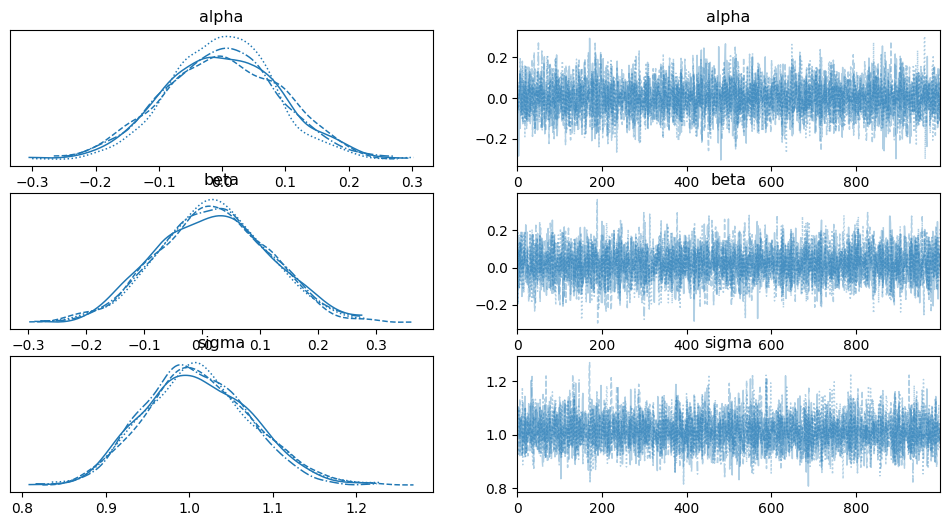

In [35]:
az.plot_trace(posterior)

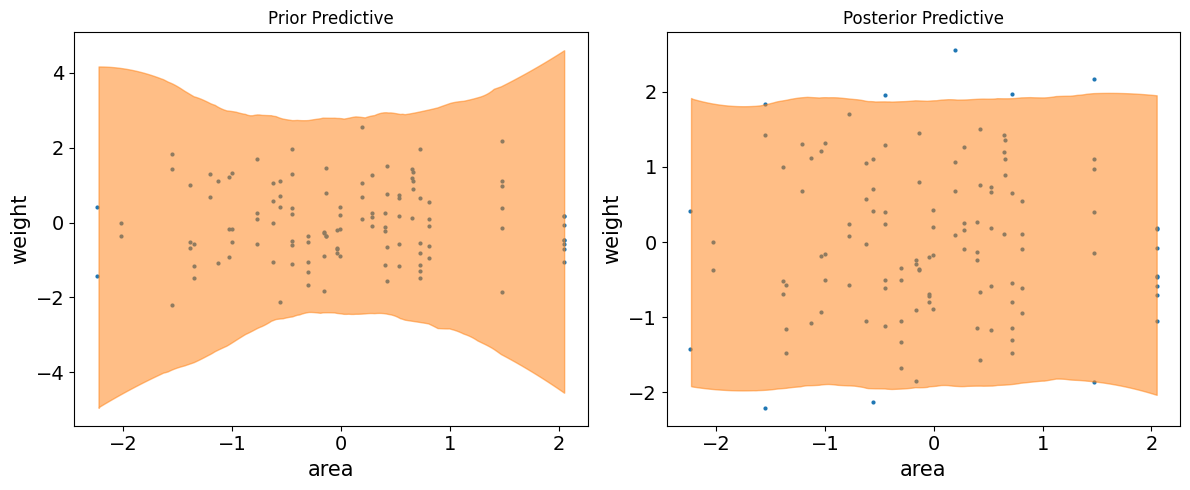

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prior predictive
az.plot_pair(
    df_foxes.select("area", "weight").to_dict(),
    ax=axes[0]
)
az.plot_hdi(
    prior_predictive.constant_data.area,
    prior_predictive.prior_predictive.weight,
    ax=axes[0]
)
axes[0].set_title("Prior Predictive")
axes[0].set_xlabel("area")
axes[0].set_ylabel("weight")

# Posterior predictive
az.plot_pair(
    df_foxes.select("area", "weight").to_dict(),
    ax=axes[1]
)
az.plot_hdi(
    posterior_predictive.constant_data.area,
    posterior_predictive.posterior_predictive.weight,
    ax=axes[1]
)
axes[1].set_title("Posterior Predictive")
axes[1].set_xlabel("area")
axes[1].set_ylabel("weight")

plt.tight_layout()